## Q10 - Bilateral Filtering


### 1 - Import Required Libraries


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


### 2 - Set Input and Output Paths


In [2]:
img_path = Path("../data/raw/einstein.png")
out_dir = Path("../results/q10")
out_dir.mkdir(parents=True, exist_ok=True)

print("Input path:", img_path.resolve())
print("Output folder:", out_dir.resolve())


Input path: D:\MSc in AI\1YQ3\CV\Assignment_1\data\raw\einstein.png
Output folder: D:\MSc in AI\1YQ3\CV\Assignment_1\results\q10


### 3 - Load Grayscale Image

In [3]:
img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")

print("Image loaded successfully")
print("Shape:", img.shape)
print("Data type:", img.dtype)


Image loaded successfully
Shape: (380, 364)
Data type: uint8


### 4 - Part (a) - Manual Bilateral Filter Function

In [4]:
def manual_bilateral_filter(img, kernel_size=5, sigma_s=3.0, sigma_r=25.0):
    """
    Manual bilateral filter for grayscale images.
    """
    if img.ndim != 2:
        raise ValueError("Input image must be grayscale.")

    pad = kernel_size // 2
    padded = np.pad(img, pad, mode="reflect")
    output = np.zeros_like(img, dtype=np.float32)

    ax = np.arange(-pad, pad + 1)
    xx, yy = np.meshgrid(ax, ax)
    spatial = np.exp(-(xx**2 + yy**2) / (2 * sigma_s**2))

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            region = padded[y:y + kernel_size, x:x + kernel_size]
            center = padded[y + pad, x + pad]

            range_weight = np.exp(-((region - center) ** 2) / (2 * sigma_r**2))
            weights = spatial * range_weight

            output[y, x] = np.sum(weights * region) / np.sum(weights)

    return np.clip(output, 0, 255).astype(np.uint8)


### 5 - Part (b) - Apply Gaussian Smoothing Using OpenCV

In [5]:
gaussian_result = cv2.GaussianBlur(img, (5, 5), sigmaX=3.0, sigmaY=3.0)
print("Part (b) completed: Gaussian smoothing applied.")


Part (b) completed: Gaussian smoothing applied.


### 6 - Part (c) - Apply Bilateral Filtering Using OpenCV

In [6]:
opencv_bilateral = cv2.bilateralFilter(img, d=5, sigmaColor=25.0, sigmaSpace=3.0)
print("Part (c) completed: OpenCV bilateral filtering applied.")


Part (c) completed: OpenCV bilateral filtering applied.


### 7 - Part (d) - Apply Manual Bilateral Filter

In [7]:
manual_bilateral = manual_bilateral_filter(img, kernel_size=5, sigma_s=3.0, sigma_r=25.0)
print("Part (d) completed: Manual bilateral filtering applied.")


Part (d) completed: Manual bilateral filtering applied.


### 8 - Display Results for Parts (b), (c), and (d)

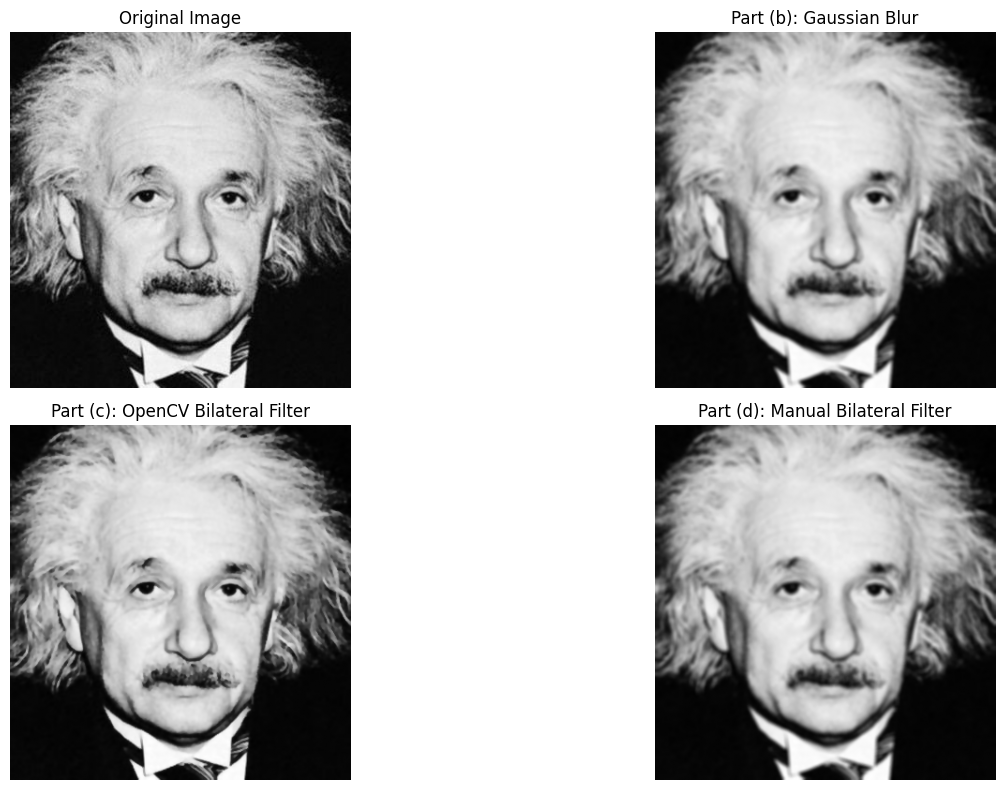

In [8]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gaussian_result, cmap="gray")
plt.title("Part (b): Gaussian Blur")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(opencv_bilateral, cmap="gray")
plt.title("Part (c): OpenCV Bilateral Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(manual_bilateral, cmap="gray")
plt.title("Part (d): Manual Bilateral Filter")
plt.axis("off")

plt.tight_layout()
plt.show()


### 9 - Save Output Images

In [9]:
cv2.imwrite(str(out_dir / "q10_original.png"), img)
cv2.imwrite(str(out_dir / "q10_gaussian.png"), gaussian_result)
cv2.imwrite(str(out_dir / "q10_opencv_bilateral.png"), opencv_bilateral)
cv2.imwrite(str(out_dir / "q10_manual_bilateral.png"), manual_bilateral)

print(f"Saved original image to: {out_dir / 'q10_original.png'}")
print(f"Saved Part (b) Gaussian result to: {out_dir / 'q10_gaussian.png'}")
print(f"Saved Part (c) OpenCV bilateral result to: {out_dir / 'q10_opencv_bilateral.png'}")
print(f"Saved Part (d) manual bilateral result to: {out_dir / 'q10_manual_bilateral.png'}")


Saved original image to: ..\results\q10\q10_original.png
Saved Part (b) Gaussian result to: ..\results\q10\q10_gaussian.png
Saved Part (c) OpenCV bilateral result to: ..\results\q10\q10_opencv_bilateral.png
Saved Part (d) manual bilateral result to: ..\results\q10\q10_manual_bilateral.png


## Interpretation and Discussion

### Part (a)
A manual bilateral filter was implemented for grayscale images. The filter combines a spatial Gaussian weight and a range Gaussian weight. This allows smoothing to occur mainly between nearby pixels with similar intensity values, which helps preserve edges.

### Part (b)
Gaussian smoothing was applied using OpenCV's `cv2.GaussianBlur()` function. This reduced noise, but also blurred edges because the filter depends only on spatial distance.

### Part (c)
OpenCV's `cv2.bilateralFilter()` was applied. Compared with Gaussian blur, it preserved important boundaries more effectively while still reducing noise.

### Part (d)
The manually implemented bilateral filter was applied to the same image. Its result was similar to the OpenCV bilateral filter, showing edge-preserving smoothing. Minor differences can occur because of border handling and implementation details.

### Conclusion
Gaussian blur smooths noise effectively but tends to blur edges. Bilateral filtering is more suitable when edge preservation is important.
